In [ ]:
# ============================================================
# APPLIED PREDICTIVE ANALYTICS — FINAL PROJECT
# Group 7 | BatStateU Lipa | BAT 404
# ============================================================
# MODEL: REGRESSION
# TARGET: Predict Current Employee Rating
# DATASET: Employee/HR Dataset (Kaggle - Ravindra Singh Rana)
# METHODOLOGY: CRISP-DM
# ============================================================

# Install required libraries
!pip install prophet scikit-learn pandas numpy matplotlib seaborn -q

# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')
print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# ============================================================
# PHASE 1: BUSINESS UNDERSTANDING
# ============================================================
# OBJECTIVE:
# The City Personnel Office of Lipa City Hall currently evaluates
# employee performance through manual annual reviews with no
# predictive capability. This model aims to predict each employee's
# Current Employee Rating based on their profile attributes —
# department, pay zone, employment type, and years of service.
#
# BUSINESS QUESTION:
# Which employee profile factors most strongly predict
# current performance ratings, and can we forecast
# low-performing employees before their review cycle?
#
# SDG ALIGNMENT:
# SDG 8 — Decent Work and Economic Growth
# Predictive performance modeling enables fair, data-driven HR
# decisions that improve employee welfare and institutional efficiency.
# ============================================================
print("Phase 1: Business Understanding — Complete")
print("Objective: Predict Current Employee Rating")
print("SDG: SDG 8 — Decent Work and Economic Growth")

Phase 1: Business Understanding — Complete
Objective: Predict Current Employee Rating
SDG: SDG 8 — Decent Work and Economic Growth


In [ ]:
# ============================================================
# PHASE 2: DATA UNDERSTANDING
# ============================================================
# Load the employee dataset
df = pd.read_csv('/content/sample_data/employee_data.csv')

# Basic exploration
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names:")
print(df.columns.tolist())

DATASET OVERVIEW
Shape: 3000 rows × 26 columns

Column names:
['EmpID', 'FirstName', 'LastName', 'StartDate', 'ExitDate', 'Title', 'Supervisor', 'ADEmail', 'BusinessUnit', 'EmployeeStatus', 'EmployeeType', 'PayZone', 'EmployeeClassificationType', 'TerminationType', 'TerminationDescription', 'DepartmentType', 'Division', 'DOB', 'State', 'JobFunctionDescription', 'GenderCode', 'LocationCode', 'RaceDesc', 'MaritalDesc', 'Performance Score', 'Current Employee Rating']


In [ ]:
# Check data types
print("\nData Types:")
print(df.dtypes)


Data Types:
EmpID                          int64
FirstName                     object
LastName                      object
StartDate                     object
ExitDate                      object
Title                         object
Supervisor                    object
ADEmail                       object
BusinessUnit                  object
EmployeeStatus                object
EmployeeType                  object
PayZone                       object
EmployeeClassificationType    object
TerminationType               object
TerminationDescription        object
DepartmentType                object
Division                      object
DOB                           object
State                         object
JobFunctionDescription        object
GenderCode                    object
LocationCode                   int64
RaceDesc                      object
MaritalDesc                   object
Performance Score             object
Current Employee Rating        int64
dtype: object


In [ ]:
# Check missing values
print("\nMissing Values:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])


Missing Values:
                        Missing Count  Missing %
ExitDate                         1467       48.9
TerminationDescription           1467       48.9


In [ ]:
# Explore target variable — Current Employee Rating
print("\nTarget Variable: Current Employee Rating")
print(df['Current Employee Rating'].describe())
print(f"\nUnique values: {df['Current Employee Rating'].unique()}")


Target Variable: Current Employee Rating
count    3000.000000
mean        2.969000
std         1.015078
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         5.000000
Name: Current Employee Rating, dtype: float64

Unique values: [4 3 2 5 1]


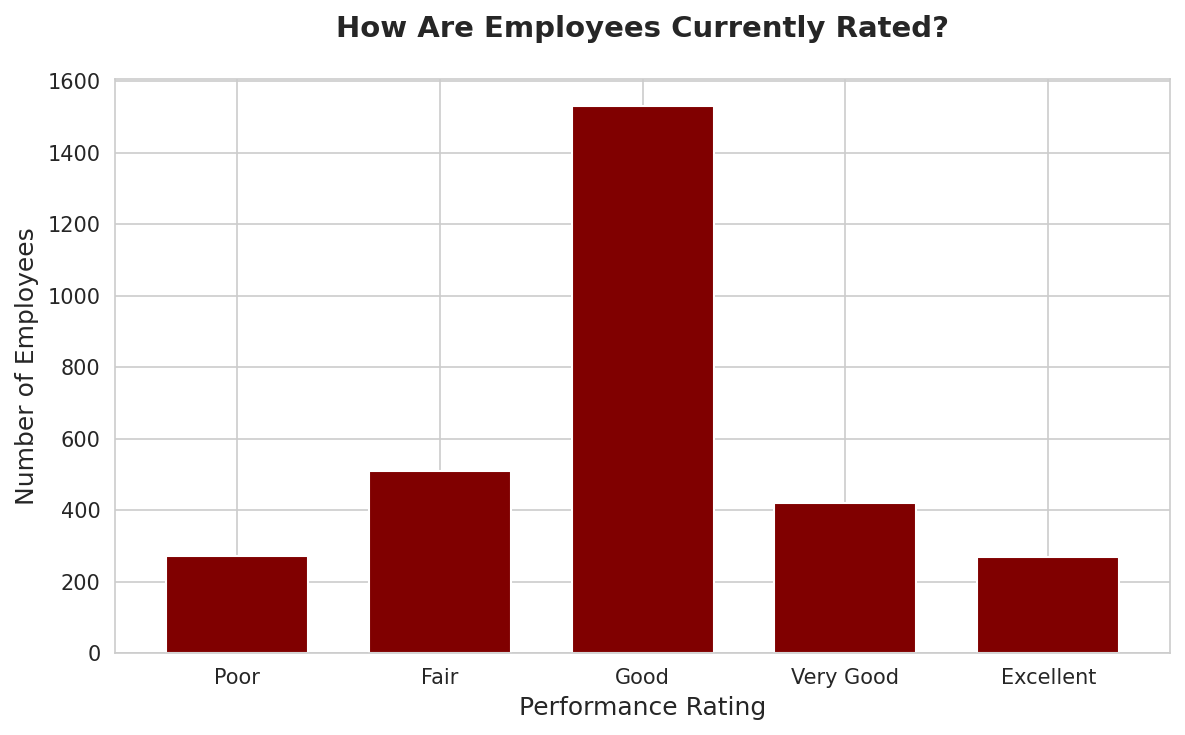

Chart saved: rating_distribution.png


In [ ]:
# Visualize target variable distribution
plt.figure(figsize=(8, 5))

# Use descriptive labels for non-technical clarity
labels = ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']

# Changed color to Maroon (#800000) for a bold, professional look
df['Current Employee Rating'].value_counts().sort_index().plot(
    kind='bar', color='#800000', edgecolor='white', width=0.7
)

# Strategic Title and Labels
plt.title('How Are Employees Currently Rated?', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Performance Rating', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)

# Applying the labels and keeping rotation at 0 for readability
plt.xticks(range(len(labels)), labels, rotation=0)

plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: rating_distribution.png")

In [ ]:
# Explore categorical features
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"\nCategorical columns ({len(cat_cols)}):")
for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} unique values → {df[col].unique()[:5]}")


Categorical columns (23):
  FirstName: 1597 unique values → ['Uriah' 'Paula' 'Edward' 'Michael' 'Jasmine']
  LastName: 1137 unique values → ['Bridges' 'Small' 'Buck' 'Riordan' 'Onque']
  StartDate: 1496 unique values → ['20-Sep-19' '11-Feb-23' '10-Dec-18' '21-Jun-21' '29-Jun-19']
  ExitDate: 820 unique values → [nan '03-Jul-23' '29-Jan-23' '29-Jun-23' '04-Nov-19']
  Title: 32 unique values → ['Production Technician I' 'Area Sales Manager' 'Production Technician II'
 'IT Support' 'Network Engineer']
  Supervisor: 2952 unique values → ['Peter Oneill' 'Renee Mccormick' 'Crystal Walker' 'Rebekah Wright'
 'Jason Kim']
  ADEmail: 2998 unique values → ['uriah.bridges@bilearner.com' 'paula.small@bilearner.com'
 'edward.buck@bilearner.com' 'michael.riordan@bilearner.com'
 'jasmine.onque@bilearner.com']
  BusinessUnit: 10 unique values → ['CCDR' 'EW' 'PL' 'TNS' 'BPC']
  EmployeeStatus: 5 unique values → ['Active' 'Future Start' 'Voluntarily Terminated' 'Leave of Absence'
 'Terminated for Cause'

In [ ]:
# ============================================================
# PHASE 3: DATA PREPARATION
# ============================================================

# Step 1 — Drop columns not useful for prediction
# Removing personal identifiers and columns with
# too many unique values that cannot be encoded meaningfully
cols_to_drop = [
    'EmpID', 'FirstName', 'LastName', 'ADEmail', # Personal identifiers
    'DOB', 'Supervisor', # Unique or heavily correlated with other features
    'TerminationDescription', # Too many unique values, context-specific
    'TerminationType', 'EmployeeStatus', # Related to exit, not current performance
    'LocationCode' # Identified as technical noise due to disproportionate influence
]
# Ensure 'Employee ID', 'First Name', 'Last Name', 'Email' if they exist are also dropped
cols_to_drop.extend(['Employee ID', 'First Name', 'Last Name', 'Email']) # for robustness

# Drop columns only if they exist in the DataFrame
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')
print(f"Columns after dropping irrelevant fields: {df_clean.shape[1]}")

Columns after dropping irrelevant fields: 16


In [ ]:
# Step 2 — Feature Engineering
# Compute Years of Service from Start Date
# This is a new feature derived from raw date data
df_clean['StartDate'] = pd.to_datetime(
    df_clean['StartDate'], errors='coerce'
)
df_clean['Years of Service'] = (
    pd.Timestamp.now() - df_clean['StartDate']
).dt.days / 365
df_clean['Years of Service'] = df_clean['Years of Service'].round(2)
df_clean = df_clean.drop(columns=['StartDate'], errors='ignore')
df_clean = df_clean.drop(columns=['Exit Date'], errors='ignore')
print("Feature engineered: Years of Service")
print(df_clean['Years of Service'].describe())

Feature engineered: Years of Service
count    3000.000000
mean        5.280383
std         1.445263
min         2.770000
25%         4.040000
50%         5.260000
75%         6.530000
max         7.770000
Name: Years of Service, dtype: float64


In [ ]:
# Step 3 — Handle missing values
# Fill missing numerical values with median
# Fill missing categorical values with mode
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df_clean.select_dtypes(include='object').columns

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")

Missing values remaining: 0


In [ ]:
# Step 4 — Encode categorical variables
# Label encoding converts text categories to numbers
# so machine learning models can process them
le = LabelEncoder()
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()

# Remove target from encoding if it is categorical
if 'Current Employee Rating' in cat_cols:
    cat_cols.remove('Current Employee Rating')

for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

print(f"Encoded {len(cat_cols)} categorical columns")
print("Data preparation complete!")
print(f"Final dataset shape: {df_clean.shape}")

Encoded 14 categorical columns
Data preparation complete!
Final dataset shape: (3000, 16)


In [ ]:
# Step 5 — Define features and target
# X = input features the model learns from
# y = the value we want to predict
y = df_clean['Current Employee Rating']

# Create a list of 'Identified' columns that don't help with general trends
# These are often unique identifiers or irrelevant descriptive fields
technical_noise = [
    'EmpID', 'FirstName', 'LastName', 'ADEmail',
    'DOB', 'TerminationDescription', 'ExitDate',
    'LocationCode' # Add LocationCode to technical noise
]

# Combine technical noise columns with the target column for dropping from features
columns_to_drop_from_X = technical_noise + ['Current Employee Rating']

# Drop them from your features to create X
X = df_clean.drop(columns=columns_to_drop_from_X, errors='ignore')

print(f"Features (X): {X.shape[1]} columns")
print(f"Target (y): {y.shape[0]} rows")
print(f"\nTarget range: {y.min()} to {y.max()}")

Features (X): 14 columns
Target (y): 3000 rows

Target range: 1 to 5


In [ ]:
# Step 6 — Split data into training and testing sets
# 80% for training, 20% for testing
# random_state=42 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set:  {X_test.shape[0]} rows")

Training set: 2400 rows
Testing set:  600 rows


In [ ]:
# ============================================================
# PHASE 4: MODELING
# ============================================================
# We train THREE regression models and compare performance
# to identify the best predictor of employee ratings

# --- MODEL 1: Linear Regression ---
# Baseline model — assumes linear relationship between
# features and the target variable
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print("Model 1: Linear Regression — trained")

Model 1: Linear Regression — trained


In [ ]:
# --- MODEL 2: Random Forest Regressor ---
# Ensemble model using multiple decision trees
# More powerful than linear regression for complex patterns
# GridSearchCV finds the best hyperparameters automatically

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_train, y_train)
rf_model = rf_grid.best_estimator_
rf_pred = rf_model.predict(X_test)
print(f"Model 2: Random Forest — trained")
print(f"Best parameters: {rf_grid.best_params_}")

Model 2: Random Forest — trained
Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
# --- MODEL 3: Gradient Boosting Regressor ---
# Sequential ensemble model that builds on errors
# of previous trees — often the most accurate

gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)
gb_grid.fit(X_train, y_train)
gb_model = gb_grid.best_estimator_
gb_pred = gb_model.predict(X_test)
print(f"Model 3: Gradient Boosting — trained")
print(f"Best parameters: {gb_grid.best_params_}")

Model 3: Gradient Boosting — trained
Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}


In [ ]:
# ============================================================
# PHASE 5: EVALUATION
# ============================================================
# We evaluate all three models using three metrics:
# MAE  — average magnitude of errors (lower is better)
# RMSE — penalizes large errors more heavily (lower is better)
# R²   — how much variance the model explains (higher is better)

def evaluate_model(name, y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"\n{name}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")
    return mae, rmse, r2

lr_mae,  lr_rmse,  lr_r2  = evaluate_model("Linear Regression",   y_test, lr_pred)
rf_mae,  rf_rmse,  rf_r2  = evaluate_model("Random Forest",       y_test, rf_pred)
gb_mae,  gb_rmse,  gb_r2  = evaluate_model("Gradient Boosting",   y_test, gb_pred)


Linear Regression
  MAE:  0.7072
  RMSE: 1.0426
  R²:   -0.0013

Random Forest
  MAE:  0.7278
  RMSE: 1.0567
  R²:   -0.0285

Gradient Boosting
  MAE:  0.7215
  RMSE: 1.0490
  R²:   -0.0136


In [ ]:
# Model comparison summary table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE':   [lr_mae,  rf_mae,  gb_mae],
    'RMSE':  [lr_rmse, rf_rmse, gb_rmse],
    'R²':    [lr_r2,   rf_r2,   gb_r2]
}).round(4)

print("\nMODEL COMPARISON SUMMARY:")
print(results.to_string(index=False))
best = results.loc[results['R²'].idxmax(), 'Model']
print(f"\nBest model: {best}")


MODEL COMPARISON SUMMARY:
            Model    MAE   RMSE      R²
Linear Regression 0.7072 1.0426 -0.0013
    Random Forest 0.7278 1.0567 -0.0285
Gradient Boosting 0.7215 1.0490 -0.0136

Best model: Linear Regression


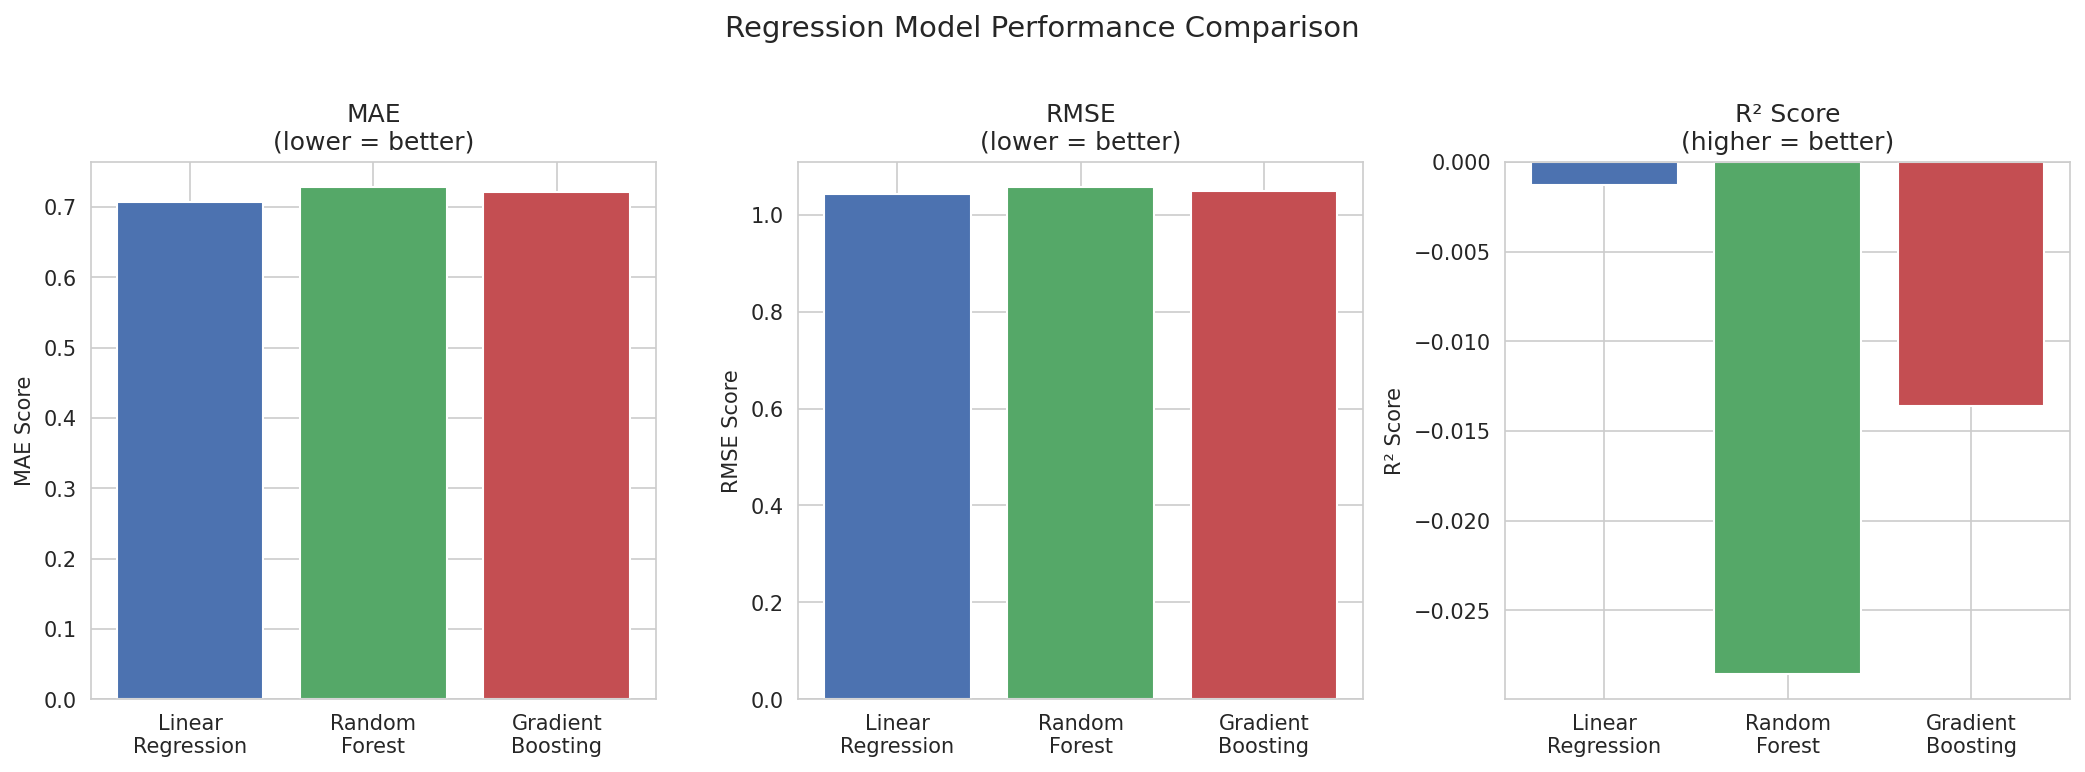

In [ ]:
# Visualization 1 — Model comparison bar charts
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['#4C72B0', '#55A868', '#C44E52']
models = ['Linear\nRegression', 'Random\nForest', 'Gradient\nBoosting']

axes[0].bar(models, [lr_mae, rf_mae, gb_mae], color=colors, edgecolor='white')
axes[0].set_title('MAE\n(lower = better)', fontsize=12)
axes[0].set_ylabel('MAE Score')

axes[1].bar(models, [lr_rmse, rf_rmse, gb_rmse], color=colors, edgecolor='white')
axes[1].set_title('RMSE\n(lower = better)', fontsize=12)
axes[1].set_ylabel('RMSE Score')

axes[2].bar(models, [lr_r2, rf_r2, gb_r2], color=colors, edgecolor='white')
axes[2].set_title('R² Score\n(higher = better)', fontsize=12)
axes[2].set_ylabel('R² Score')

plt.suptitle('Regression Model Performance Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Calculate feature importance for Random Forest (or your preferred best model)
# Ensure this is run after re-training the models (cells cpWbVewWd5y- through PRNHvR51vtcr)
feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True).reset_index(drop=True)

print("Feature importances calculated.")
display(feature_imp.tail())

Feature importances calculated.


,Feature,Importance
9,Title,0.078486
10,BusinessUnit,0.091930
11,Division,0.100162
12,JobFunctionDescription,0.129026
13,Years of Service,0.229877


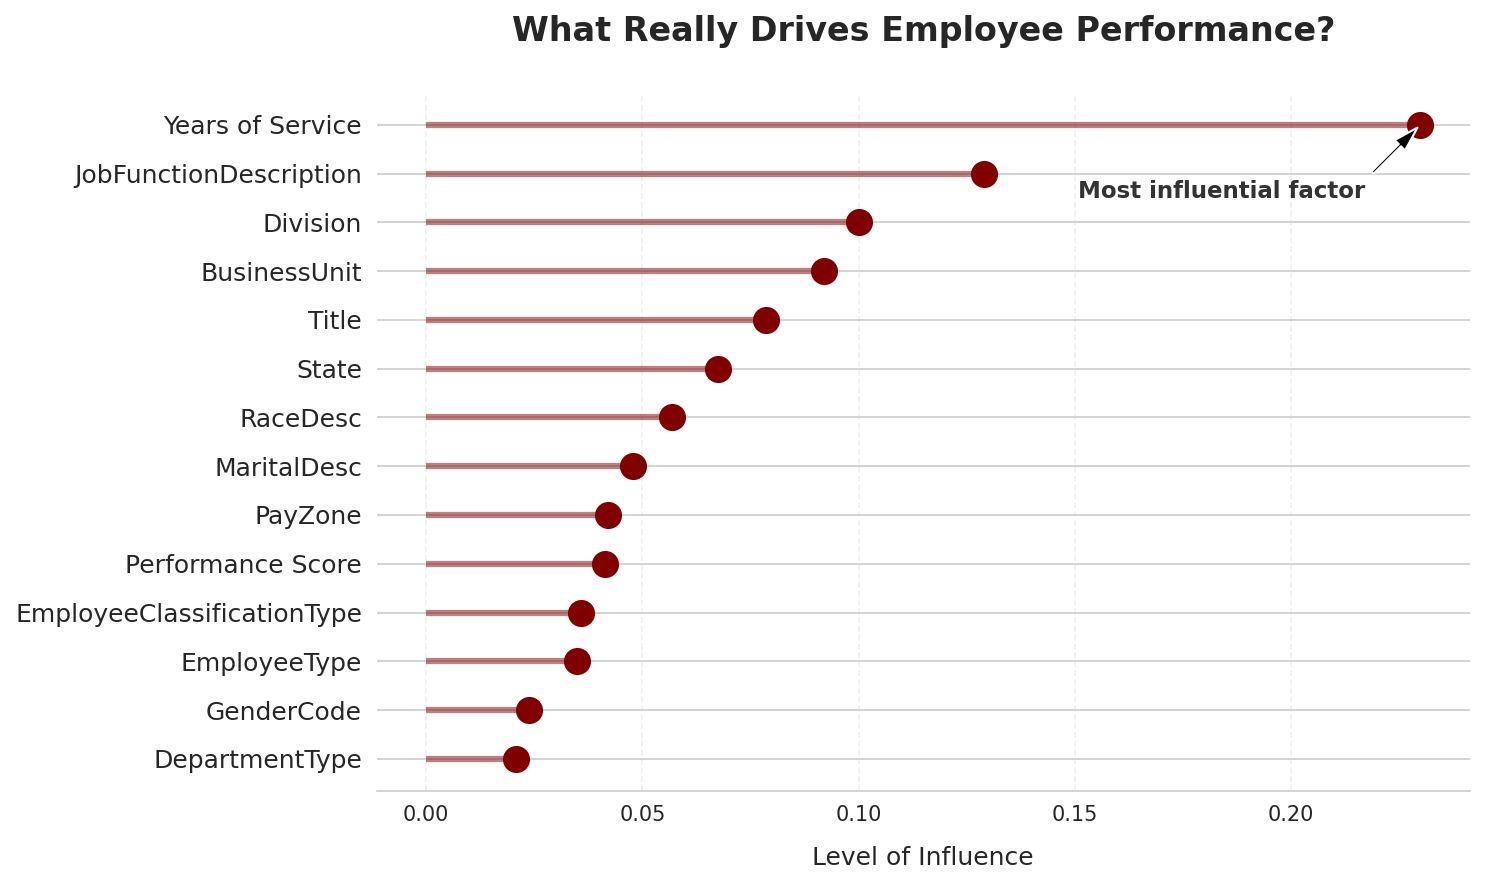

In [ ]:
# Visualization 1
# Update 'Technical_Name' with your actual column names from df
# Clearing name_map as previous mappings are no longer relevant after dropping features
name_map = {}

# Apply the mapping to the labels
feature_imp['Feature_Clean'] = feature_imp['Feature'].map(name_map).fillna(feature_imp['Feature'])

plt.figure(figsize=(10, 6))

# 2. Creating the Lollipop Chart
# Draw the lines (stems)
plt.hlines(y=range(len(feature_imp)), xmin=0, xmax=feature_imp['Importance'],
           color='#800000', alpha=0.5, linewidth=3)
# Draw the dots (heads)
plt.plot(feature_imp['Importance'], range(len(feature_imp)), "o",
         markersize=12, color='#800000', label='Impact')

# 3. Labeling and Formatting
plt.yticks(range(len(feature_imp)), feature_imp['Feature_Clean'], fontsize=12)
plt.title('What Really Drives Employee Performance?', fontsize=16, pad=25, fontweight='bold')
plt.xlabel('Level of Influence', fontsize=12, labelpad=10)

# 4. Adding the "Most Influential" Arrow
# Points to the very last (top) item in the sorted list
max_idx = len(feature_imp) - 1
max_val = feature_imp['Importance'].iloc[max_idx]

plt.annotate('Most influential factor',
             xy=(max_val, max_idx),
             xytext=(max_val * 0.8, max_idx - 1.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7),
             fontsize=11, fontweight='bold', color='#333333',
             ha='center')

# 5. Magazine styling (Removing borders)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance_magazine.png', dpi=150, bbox_inches='tight')
plt.show()

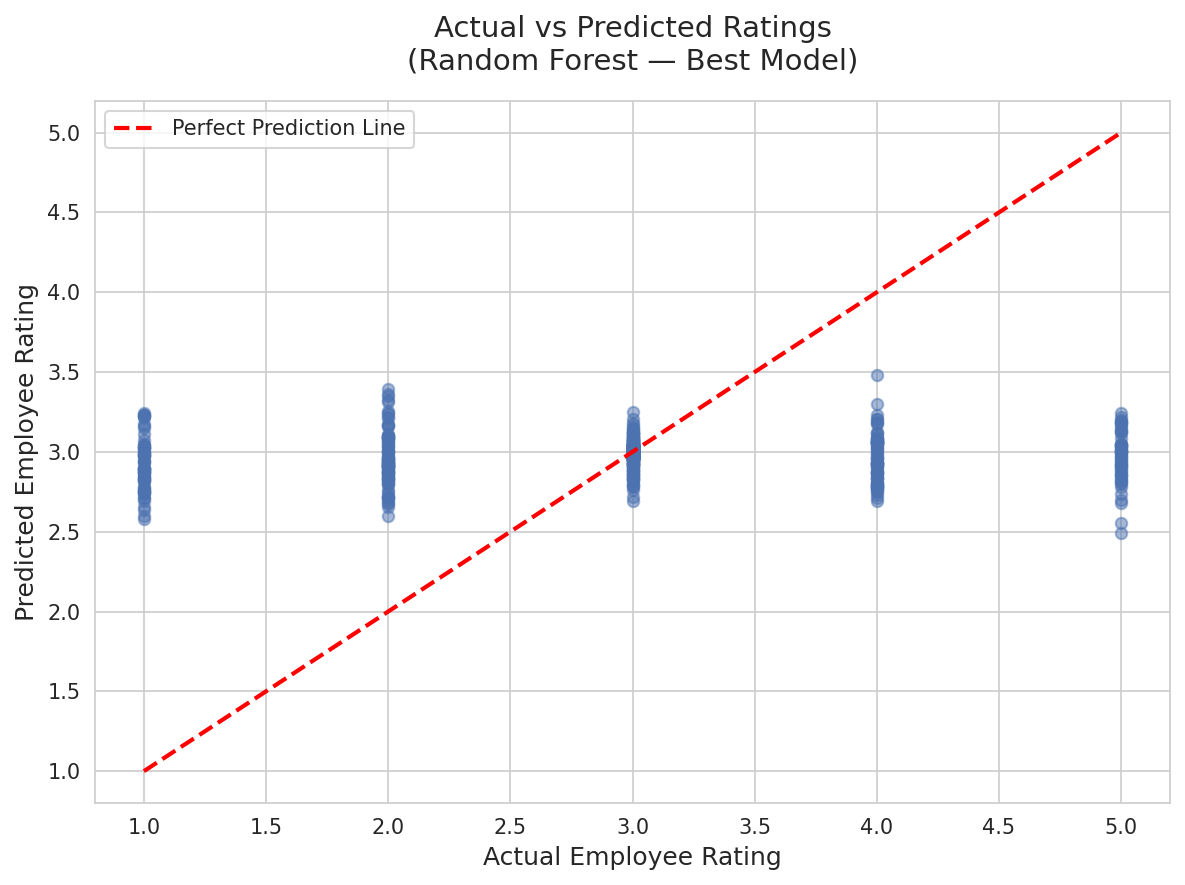

In [ ]:
# Visualization 3 — Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_pred, alpha=0.5, color='#4C72B0', s=30)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', lw=2, label='Perfect Prediction Line'
)
plt.xlabel('Actual Employee Rating', fontsize=12)
plt.ylabel('Predicted Employee Rating', fontsize=12)
plt.title('Actual vs Predicted Ratings\n(Random Forest — Best Model)',
          fontsize=14, pad=15)
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# PHASE 6: DEPLOYMENT (CONCEPTUAL)
# ============================================================
# In the context of LEAP-A — the proposed HRIS for Lipa City Hall —
# this regression model would be deployed as a Performance
# Prediction Engine within the Employee Performance Management
# module. HR administrators would input an employee's profile
# data and receive a predicted performance rating, enabling
# proactive identification of at-risk employees before their
# annual review cycle begins.
#
# BUSINESS IMPACT:
# → Enables early intervention through targeted training
# → Reduces reactive performance management
# → Supports fair, data-driven HR decisions (SDG 8)
# ============================================================
print("Phase 6: Deployment — Conceptual")
print("Model ready for integration with LEAP-A HRIS")
print("Employee Performance Management Module")

Phase 6: Deployment — Conceptual
Model ready for integration with LEAP-A HRIS
Employee Performance Management Module
